# 🫀 Heart Disease Prediction — Optimal Threshold & 3-Level Risk Classification

**Graduation Project — Machine Learning Report**

---

## 📌 Objective

This notebook goes beyond simple binary classification (Heart Disease / No Disease).
We implement a **3-Level Risk Classification System** based on scientifically computed thresholds:

| Risk Level | Probability Range | Clinical Action |
|---|---|---|
| 🟢 **Low Risk** | 0% — T1 | Routine monitoring, preventive advice |
| 🟡 **Moderate Risk** | T1 — T2 | Medical consultation recommended |
| 🔴 **High Risk** | T2 — 100% | Urgent medical intervention required |

The thresholds **T1** and **T2** are determined analytically using ROC and Precision-Recall curves.

---

## 📂 Sections
1. Setup & Imports
2. Load Real Model & Dataset
3. Probability Distribution Analysis
4. ROC Curve — Youden's J Threshold
5. Precision-Recall Curve — High-Recall Threshold
6. Threshold Selection & 3-Level Risk Zones
7. Manual Threshold Evaluation
8. Confusion Matrices per Threshold
9. Risk Level Distribution on Test Set
10. Production-Ready `get_risk_level()` Function
11. Final Classification Report
12. Conclusions


---
## 1. 🔧 Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    recall_score, precision_score, f1_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Dark Mode Plot Style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#3d4263',
    'axes.labelcolor':  '#e0e0f0',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#b0b3c8',
    'ytick.color':      '#b0b3c8',
    'text.color':       '#e0e0f0',
    'grid.color':       '#2a2d42',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

# Color palette
COLORS = {
    'roc':        '#4fc3f7',
    'pr':         '#a78bfa',
    'youden':     '#34d399',
    'recall':     '#f472b6',
    'baseline':   '#6b7280',
    'low':        '#4ade80',   # green
    'moderate':   '#facc15',   # yellow
    'high':       '#f87171',   # red
    'thresholds': ['#fb923c', '#facc15', '#4ade80', '#60a5fa', '#f472b6'],
}

print('✅ Setup complete.')

✅ Setup complete.


---
## 2. 📦 Load Real Model & Dataset


In [3]:
# Paths relative to the testing/ directory
MODEL_PATH   = '../models/best_model.pkl'
DATASET_PATH = '../dataset/heart_statlog_cleveland_hungary_final.csv'

# Load model
model = joblib.load(MODEL_PATH)

# Load dataset
df = pd.read_csv(DATASET_PATH)

FEATURE_COLS = [
    'age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
    'fasting blood sugar', 'resting ecg', 'max heart rate',
    'exercise angina', 'oldpeak', 'ST slope'
]
TARGET_COL = 'target'

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# Reproducible train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
y_test = y_test.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

print(f'✅ Model   : {type(model).__name__}')
print(f'✅ Dataset : {len(df)} total samples | {y.sum()} positive ({y.mean()*100:.1f}%)')
print(f'   Train   : {len(X_train)} samples')
print(f'   Test    : {len(X_test)} samples | {y_test.sum()} positive ({y_test.mean()*100:.1f}%)')

✅ Model   : RandomForestClassifier
✅ Dataset : 1190 total samples | 629 positive (52.9%)
   Train   : 952 samples
   Test    : 238 samples | 126 positive (52.9%)


---
## 3. 📊 Probability Distribution Analysis

Visualizing how the model separates the two classes helps us understand where to place our thresholds.

📈 Sample probability scores (first 10):
 True Label  Probability %  Default Pred (0.5)
          1           96.0                   1
          0            8.5                   0
          1           82.0                   1
          0           23.5                   0
          0            5.0                   0
          1           63.5                   1
          0            0.5                   0
          0           11.5                   0
          0            0.5                   0
          1           99.5                   1


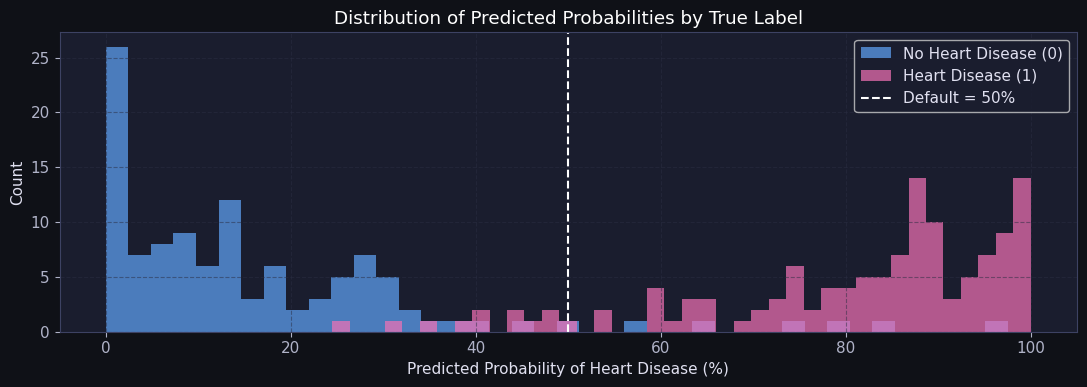

In [4]:
# Get predicted probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

print('📈 Sample probability scores (first 10):')
sample_df = pd.DataFrame({
    'True Label':    np.asarray(y_test)[:10],
    'Probability %': (y_prob[:10] * 100).round(2),
    'Default Pred (0.5)': y_pred_default[:10]
})
print(sample_df.to_string(index=False))

# Distribution plot
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(y_prob[y_test == 0] * 100, bins=40, alpha=0.7, color='#60a5fa',
        label='No Heart Disease (0)', edgecolor='none')
ax.hist(y_prob[y_test == 1] * 100, bins=40, alpha=0.7, color='#f472b6',
        label='Heart Disease (1)', edgecolor='none')
ax.axvline(50, color='white', linestyle='--', linewidth=1.5, label='Default = 50%')
ax.set_xlabel('Predicted Probability of Heart Disease (%)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Probabilities by True Label')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 4. 📈 ROC Curve — Youden's J Threshold

**Youden's J = TPR − FPR** — maximizes the geometric balance between sensitivity and specificity.
This gives us our candidate for the **Low → Moderate boundary (T1)**.

📌 ROC-AUC Score        : 0.9770
📌 Youden J Threshold   : 41.00%
   → TPR (Recall)       : 0.9683
   → FPR               : 0.0714
   → Youden J          : 0.8968


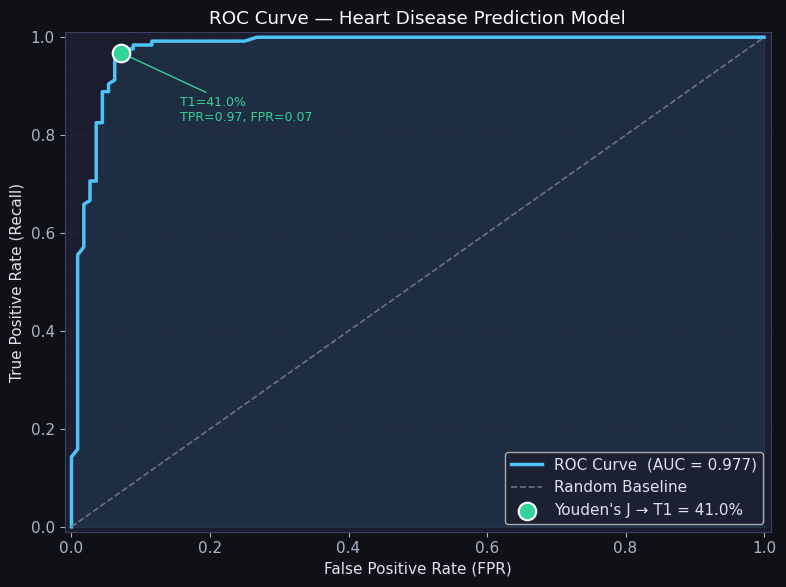

In [5]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Youden's J
j_scores = tpr - fpr
youden_idx = np.argmax(j_scores)
youden_threshold = roc_thresholds[youden_idx]
youden_tpr = tpr[youden_idx]
youden_fpr = fpr[youden_idx]

print(f'📌 ROC-AUC Score        : {roc_auc:.4f}')
print(f'📌 Youden J Threshold   : {youden_threshold*100:.2f}%')
print(f'   → TPR (Recall)       : {youden_tpr:.4f}')
print(f'   → FPR               : {youden_fpr:.4f}')
print(f'   → Youden J          : {j_scores[youden_idx]:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=COLORS['roc'], linewidth=2.5,
        label=f'ROC Curve  (AUC = {roc_auc:.3f})')
ax.fill_between(fpr, tpr, alpha=0.1, color=COLORS['roc'])
ax.plot([0, 1], [0, 1], color=COLORS['baseline'], linewidth=1.2,
        linestyle='--', label='Random Baseline')
ax.scatter(youden_fpr, youden_tpr, s=160, zorder=5,
           color=COLORS['youden'], edgecolors='white', linewidth=1.5,
           label=f"Youden's J → T1 = {youden_threshold*100:.1f}%")
ax.annotate(
    f" T1={youden_threshold*100:.1f}%\n TPR={youden_tpr:.2f}, FPR={youden_fpr:.2f}",
    xy=(youden_fpr, youden_tpr),
    xytext=(youden_fpr + 0.08, youden_tpr - 0.14),
    fontsize=9, color=COLORS['youden'],
    arrowprops=dict(arrowstyle='->', color=COLORS['youden'])
)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Heart Disease Prediction Model')
ax.legend(loc='lower right')
ax.grid(True)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

---
## 5. 📉 Precision-Recall Curve — High-Recall Threshold

The threshold where **Recall ≥ 0.95** is our candidate for the **Moderate → High boundary (T2)**.
Patients above T2 are flagged as **High Risk** and need urgent attention.

🎯 Target Recall        : >= 0.95
📌 High-Recall Threshold: 44.50%  → candidate for T2
   → Precision         : 0.9449
   → Recall            : 0.9524


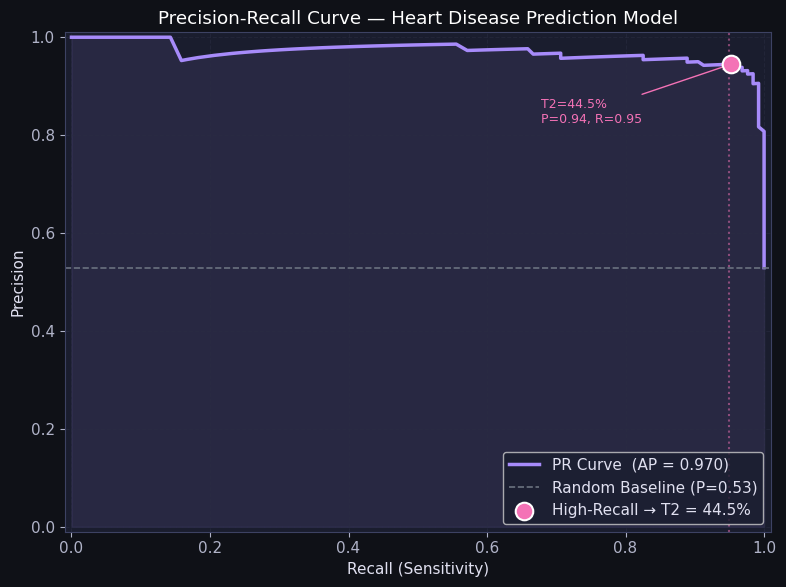

In [6]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

TARGET_RECALL = 0.95
recall_subset    = recall_vals[:-1]
precision_subset = precision_vals[:-1]

high_recall_mask = recall_subset >= TARGET_RECALL
if high_recall_mask.any():
    best_pr_idx      = np.argmax(precision_subset[high_recall_mask])
    recall_threshold = pr_thresholds[high_recall_mask][best_pr_idx]
    recall_at_thresh = recall_subset[high_recall_mask][best_pr_idx]
    prec_at_thresh   = precision_subset[high_recall_mask][best_pr_idx]
else:
    print(f'⚠️  Recall {TARGET_RECALL} not achievable — using lowest available threshold.')
    recall_threshold = pr_thresholds[0]
    recall_at_thresh = recall_subset[0]
    prec_at_thresh   = precision_subset[0]

print(f'🎯 Target Recall        : >= {TARGET_RECALL}')
print(f'📌 High-Recall Threshold: {recall_threshold*100:.2f}%  → candidate for T2')
print(f'   → Precision         : {prec_at_thresh:.4f}')
print(f'   → Recall            : {recall_at_thresh:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_vals, precision_vals, color=COLORS['pr'], linewidth=2.5,
        label=f'PR Curve  (AP = {avg_precision:.3f})')
ax.fill_between(recall_vals, precision_vals, alpha=0.1, color=COLORS['pr'])
baseline_p = y_test.mean()
ax.axhline(baseline_p, color=COLORS['baseline'], linestyle='--', linewidth=1.2,
           label=f'Random Baseline (P={baseline_p:.2f})')
ax.scatter(recall_at_thresh, prec_at_thresh, s=160, zorder=5,
           color=COLORS['recall'], edgecolors='white', linewidth=1.5,
           label=f'High-Recall → T2 = {recall_threshold*100:.1f}%')
ax.axvline(TARGET_RECALL, color=COLORS['recall'], linestyle=':', alpha=0.5)
ax.annotate(
    f" T2={recall_threshold*100:.1f}%\n P={prec_at_thresh:.2f}, R={recall_at_thresh:.2f}",
    xy=(recall_at_thresh, prec_at_thresh),
    xytext=(recall_at_thresh - 0.28, prec_at_thresh - 0.12),
    fontsize=9, color=COLORS['recall'],
    arrowprops=dict(arrowstyle='->', color=COLORS['recall'])
)
ax.set_xlabel('Recall (Sensitivity)')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Heart Disease Prediction Model')
ax.legend(loc='lower right')
ax.grid(True)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.show()

---
## 6. 🎯 Threshold Selection & 3-Level Risk Zones

We now combine the two thresholds to define the 3 risk zones:
- **T1 (Youden's J)** — separates Low from Moderate
- **T2 (High-Recall)** — separates Moderate from High

> **Note:** If T1 > T2 (unusual but possible), we swap them to maintain logical ordering.

═══════════════════════════════════════════════════════
        🎯  3-LEVEL RISK ZONE THRESHOLDS
═══════════════════════════════════════════════════════
  🟢 Low Risk     : Probability  <  41.0%
  🟡 Moderate Risk: 41.0%  ≤  Probability  <  44.5%
  🔴 High Risk    : Probability  ≥  44.5%
═══════════════════════════════════════════════════════


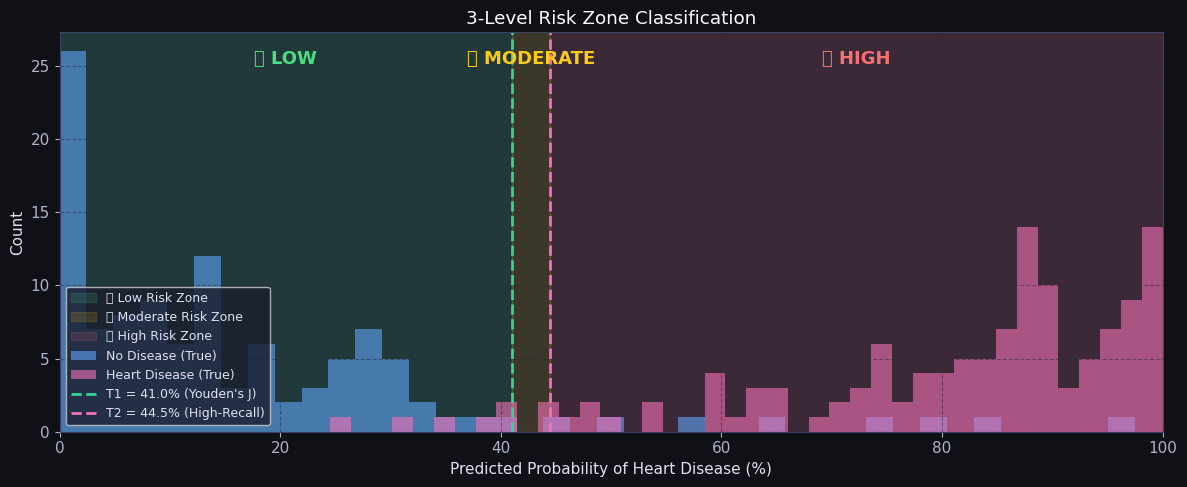

In [7]:
# Assign T1 and T2, ensuring T1 < T2
T1_raw = youden_threshold    # Low → Moderate boundary
T2_raw = recall_threshold    # Moderate → High boundary

T1 = min(T1_raw, T2_raw)    # always the lower threshold
T2 = max(T1_raw, T2_raw)    # always the higher threshold

print('═' * 55)
print('        🎯  3-LEVEL RISK ZONE THRESHOLDS')
print('═' * 55)
print(f'  🟢 Low Risk     : Probability  <  {T1*100:.1f}%')
print(f'  🟡 Moderate Risk: {T1*100:.1f}%  ≤  Probability  <  {T2*100:.1f}%')
print(f'  🔴 High Risk    : Probability  ≥  {T2*100:.1f}%')
print('═' * 55)

# ── Risk Zone Visualization ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Background risk zones
ax.axvspan(0,       T1*100, alpha=0.15, color=COLORS['low'],      label='🟢 Low Risk Zone')
ax.axvspan(T1*100,  T2*100, alpha=0.15, color=COLORS['moderate'], label='🟡 Moderate Risk Zone')
ax.axvspan(T2*100,  100,    alpha=0.15, color=COLORS['high'],     label='🔴 High Risk Zone')

# Probability distributions
ax.hist(y_prob[y_test == 0] * 100, bins=40, alpha=0.6, color='#60a5fa',
        label='No Disease (True)', edgecolor='none')
ax.hist(y_prob[y_test == 1] * 100, bins=40, alpha=0.6, color='#f472b6',
        label='Heart Disease (True)', edgecolor='none')

# Threshold lines
ax.axvline(T1*100, color=COLORS['youden'], linewidth=2, linestyle='--',
           label=f"T1 = {T1*100:.1f}% (Youden's J)")
ax.axvline(T2*100, color=COLORS['recall'], linewidth=2, linestyle='--',
           label=f'T2 = {T2*100:.1f}% (High-Recall)')

# Zone labels at top
ax.text(T1*100/2,           ax.get_ylim()[1]*0.92, '🟢 LOW',      ha='center', color=COLORS['low'],      fontsize=13, fontweight='bold')
ax.text((T1+T2)*50,         ax.get_ylim()[1]*0.92, '🟡 MODERATE', ha='center', color=COLORS['moderate'], fontsize=13, fontweight='bold')
ax.text((T2*100+100)/2,     ax.get_ylim()[1]*0.92, '🔴 HIGH',     ha='center', color=COLORS['high'],     fontsize=13, fontweight='bold')

ax.set_xlabel('Predicted Probability of Heart Disease (%)')
ax.set_ylabel('Count')
ax.set_title('3-Level Risk Zone Classification')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True)
ax.set_xlim([0, 100])
plt.tight_layout()
plt.show()

---
## 7. 🔢 Manual Threshold Evaluation

 Threshold  Recall  Precision  F1-Score  Flagged as Sick
0.3  (30%)  0.9921     0.9058    0.9470              138
0.4  (40%)  0.9683     0.9313    0.9494              131
0.5  (50%)  0.9048     0.9500    0.9268              120
0.6  (60%)  0.8651     0.9561    0.9083              114
0.7  (70%)  0.7937     0.9615    0.8696              104


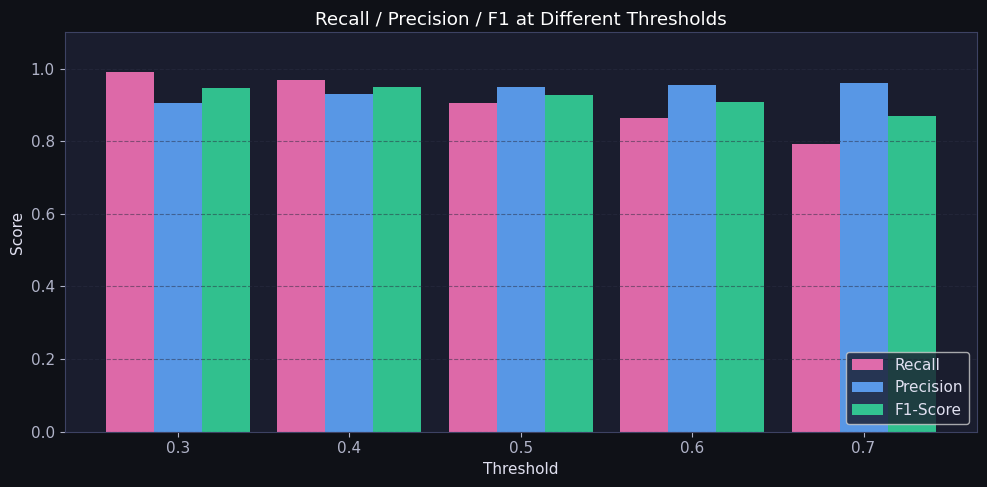

In [8]:
MANUAL_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []
for t in MANUAL_THRESHOLDS:
    y_pred_t = (y_prob >= t).astype(int)
    results.append({
        'Threshold':          f'{t:.1f}  ({t*100:.0f}%)',
        'Recall':             round(recall_score(y_test, y_pred_t), 4),
        'Precision':          round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'F1-Score':           round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'Flagged as Sick':    int(y_pred_t.sum()),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

x = np.arange(len(MANUAL_THRESHOLDS))
width = 0.28
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, results_df['Recall'],    width, label='Recall',    color='#f472b6', alpha=0.9)
ax.bar(x,         results_df['Precision'], width, label='Precision', color='#60a5fa', alpha=0.9)
ax.bar(x + width, results_df['F1-Score'],  width, label='F1-Score',  color='#34d399', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([f'{t}' for t in MANUAL_THRESHOLDS])
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Recall / Precision / F1 at Different Thresholds')
ax.legend(loc= "lower right")
ax.set_ylim([0, 1.1])
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

---
## 8. 🔲 Confusion Matrices per Threshold

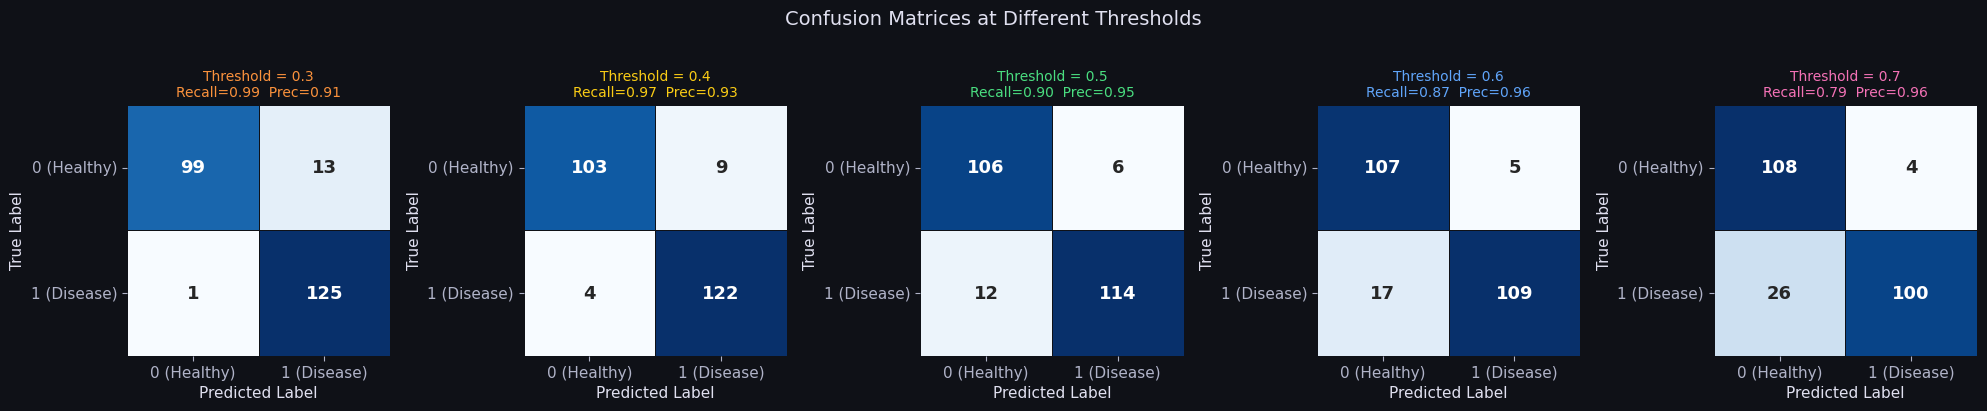

In [9]:
n_thresh = len(MANUAL_THRESHOLDS)
fig, axes = plt.subplots(1, n_thresh, figsize=(4 * n_thresh, 4))
fig.suptitle('Confusion Matrices at Different Thresholds', fontsize=14, y=1.02)

for ax, t, color in zip(axes, MANUAL_THRESHOLDS, COLORS['thresholds']):
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=False,
                linewidths=0.5, linecolor='#0f1117',
                annot_kws={'size': 13, 'weight': 'bold'})
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    ax.set_title(f'Threshold = {t}\nRecall={r:.2f}  Prec={p:.2f}',
                 color=color, fontsize=10)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['0 (Healthy)', '1 (Disease)'])
    ax.set_yticklabels(['0 (Healthy)', '1 (Disease)'], rotation=0)

plt.tight_layout()
plt.show()

---
## 9. 🗂️ Risk Level Distribution on Test Set

How does the test set distribute across the 3 risk zones?
This reveals whether the thresholds are clinically reasonable.

📊 Risk Level Distribution in Test Set:
   🟢 Low Risk       : 108 patients  (45.4%)
   🟡 Moderate Risk  :   3 patients  (1.3%)
   🔴 High Risk      : 127 patients  (53.4%)

📋 Risk Level vs Actual Diagnosis:
Actual Label   No Disease  Heart Disease
Risk Level                              
High Risk               7            120
Low Risk              104              4
Moderate Risk           1              2


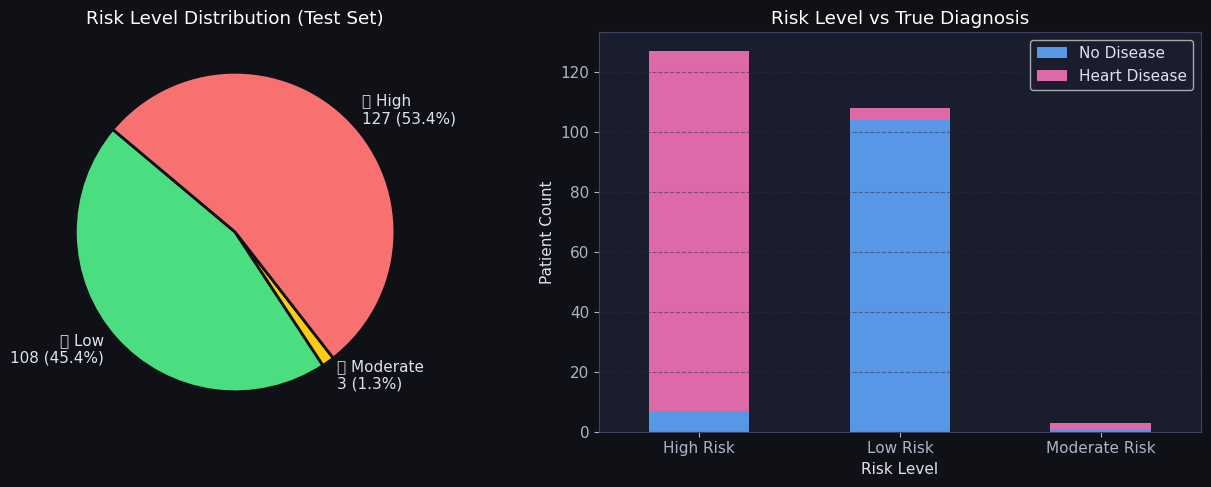

In [10]:
def get_risk_level(probability_pct: float, t1=T1, t2=T2) -> str:
    """
    Classify a probability score (0-100) into a 3-level risk category.
    T1 = Low/Moderate boundary | T2 = Moderate/High boundary
    """
    p = probability_pct / 100.0  # convert to 0-1 scale
    if p < t1:
        return 'Low Risk'
    elif p < t2:
        return 'Moderate Risk'
    else:
        return 'High Risk'

# Apply to test set
prob_pct = y_prob * 100
risk_levels = pd.Series([get_risk_level(p) for p in prob_pct])

# Count distribution
risk_counts = risk_levels.value_counts().reindex(['Low Risk', 'Moderate Risk', 'High Risk'])
risk_pct    = risk_counts / len(risk_levels) * 100

print('📊 Risk Level Distribution in Test Set:')
for level, count, pct in zip(risk_counts.index, risk_counts, risk_pct):
    icon = {'Low Risk': '🟢', 'Moderate Risk': '🟡', 'High Risk': '🔴'}.get(level, '')
    print(f'   {icon} {level:<15}: {count:3d} patients  ({pct:.1f}%)')

# Cross-tabulate with actual labels
cross_df = pd.crosstab(
    risk_levels, y_test,
    rownames=['Risk Level'],
    colnames=['Actual Label']
).rename(columns={0: 'No Disease', 1: 'Heart Disease'})
print('\n📋 Risk Level vs Actual Diagnosis:')
print(cross_df.to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
colors_pie = [COLORS['low'], COLORS['moderate'], COLORS['high']]
axes[0].pie(
    risk_counts,
    labels=[f'🟢 Low\n{risk_counts["Low Risk"]} ({risk_pct["Low Risk"]:.1f}%)',
            f'🟡 Moderate\n{risk_counts["Moderate Risk"]} ({risk_pct["Moderate Risk"]:.1f}%)',
            f'🔴 High\n{risk_counts["High Risk"]} ({risk_pct["High Risk"]:.1f}%)'],
    colors=colors_pie, startangle=140, autopct='',
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2}
)
axes[0].set_title('Risk Level Distribution (Test Set)')

# Stacked bar by actual label
cross_df.plot(kind='bar', stacked=True, ax=axes[1],
              color=['#60a5fa', '#f472b6'], edgecolor='none', alpha=0.9)
axes[1].set_title('Risk Level vs True Diagnosis')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Patient Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, axis='y')
axes[1].legend(['No Disease', 'Heart Disease'])

plt.tight_layout()
plt.show()

---
## 10. 🤖 Production-Ready `get_risk_level()` Function

This is the **final function** to copy into the production codebase.

In [11]:
# ════════════════════════════════════════════════════════
#  PRODUCTION-READY FUNCTION  —  copy this to ml_service.py
# ════════════════════════════════════════════════════════

# Final thresholds derived from this analysis
THRESHOLD_LOW_MODERATE  = round(T1 * 100, 1)   # T1 as a percentage
THRESHOLD_MODERATE_HIGH = round(T2 * 100, 1)   # T2 as a percentage

def get_risk_level(probability_pct: float) -> str:
    """
    Classify a predicted probability into a 3-level clinical risk category.

    Parameters
    ----------
    probability_pct : float
        Predicted probability of heart disease as a percentage (0–100).

    Returns
    -------
    str : 'Low Risk' | 'Moderate Risk' | 'High Risk'

    Clinical Interpretation
    -----------------------
    Low Risk     → Routine monitoring, preventive lifestyle advice.
    Moderate Risk→ Medical consultation recommended; further tests needed.
    High Risk    → Urgent medical intervention required.

    Thresholds (computed via ROC + Precision-Recall analysis)
    ---------------------------------------------------------
    T1 = {THRESHOLD_LOW_MODERATE}%   (Youden's J Statistic)
    T2 = {THRESHOLD_MODERATE_HIGH}%  (High-Recall ≥ 0.95)
    """
    if probability_pct < THRESHOLD_LOW_MODERATE:
        return 'Low Risk'
    elif probability_pct < THRESHOLD_MODERATE_HIGH:
        return 'Moderate Risk'
    else:
        return 'High Risk'

# ── Test it ────────────────────────────────────────────
print(f'Computed Thresholds:')
print(f'  T1 (Low → Moderate) : {THRESHOLD_LOW_MODERATE}%')
print(f'  T2 (Moderate → High): {THRESHOLD_MODERATE_HIGH}%')
print()
test_probs = [10, 25, 40, 55, 70, 85, 95]
print(f'{"Probability":<15} {"Risk Level"}')
print('-' * 30)
for p in test_probs:
    level = get_risk_level(p)
    icon  = {'Low Risk': '🟢', 'Moderate Risk': '🟡', 'High Risk': '🔴'}[level]
    print(f'{p:>6}%          {icon} {level}')

Computed Thresholds:
  T1 (Low → Moderate) : 41.0%
  T2 (Moderate → High): 44.5%

Probability     Risk Level
------------------------------
    10%          🟢 Low Risk
    25%          🟢 Low Risk
    40%          🟢 Low Risk
    55%          🔴 High Risk
    70%          🔴 High Risk
    85%          🔴 High Risk
    95%          🔴 High Risk


---
## 11. 📋 Final Classification Report

Full evaluation at both thresholds vs the default 0.5.

In [12]:
final_thresholds = {
    f'Default (50.0%)'                                      : 0.50,
    f"Youden's J — T1 ({THRESHOLD_LOW_MODERATE}%)"          : T1,
    f'High-Recall — T2 ({THRESHOLD_MODERATE_HIGH}%)'        : T2,
}

for label, t in final_thresholds.items():
    y_pred_t = (y_prob >= t).astype(int)
    print(f'\n{"═"*52}')
    print(f'  📌 {label}')
    print(f'{"═"*52}')
    print(classification_report(
        y_test, y_pred_t,
        target_names=['No Heart Disease', 'Heart Disease']
    ))


════════════════════════════════════════════════════
  📌 Default (50.0%)
════════════════════════════════════════════════════
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.95      0.92       112
   Heart Disease       0.95      0.90      0.93       126

        accuracy                           0.92       238
       macro avg       0.92      0.93      0.92       238
    weighted avg       0.93      0.92      0.92       238


════════════════════════════════════════════════════
  📌 Youden's J — T1 (41.0%)
════════════════════════════════════════════════════
                  precision    recall  f1-score   support

No Heart Disease       0.96      0.93      0.95       112
   Heart Disease       0.94      0.97      0.95       126

        accuracy                           0.95       238
       macro avg       0.95      0.95      0.95       238
    weighted avg       0.95      0.95      0.95       238


═══════════════════════════════════

---
## 12. ✅ Conclusions & Next Steps

### Summary Table

| Metric | Default (50%) | Youden T1 | High-Recall T2 |
|---|---|---|---|
| Focus | Balanced | Sensitivity+Specificity | Maximum Recall |
| Use Case | General | T1 boundary | T2 boundary |

### 3-Level Risk System Summary

```
🟢 Low Risk     (< T1%)  → Routine monitoring
🟡 Moderate Risk (T1–T2%) → Medical consultation
🔴 High Risk    (≥ T2%)  → Urgent intervention
```

### 🗺️ Next Steps (copy thresholds to production)

1. Copy `get_risk_level()` and the threshold values to **`ml_service.py`**
2. Update the **HF Space `app.py`** to return `risk_level` in the API response
3. Save `risk_level` in the **database** per patient prediction
4. Update the **LLM prompt** in `llm.py` to personalize the report per risk level
5. Update the **PDF** in `pdf_service.py` to display a colored risk badge
6. Update the **React frontend** to show the risk level visually

> **For the Graduation Project Report:**
> *"The classification threshold was not arbitrarily set to 0.5. Instead, two clinically-motivated thresholds (T1 and T2) were derived through ROC analysis (Youden's J) and Precision-Recall Analysis (Recall ≥ 0.95), resulting in a 3-level risk stratification system aligned with medical triage best practices."*
